## Complementary EDA: Advanced Insights

This section extends the initial exploratory analysis by integrating external datasets, including property tax and crime data.

The objective is to better understand the key drivers of housing prices in Vancouver and prepare the dataset for predictive modeling.

This analysis focuses on:
- Feature engineering from raw data
- Understanding distributions and skewness
- Exploring relationships between variables
- Segmenting the housing market
- Integrating external factors such as crime

In [2]:
import os
print(os.getcwd())

d:\Documents\Term2\CPSC-4810-M01\Final Project\vancouver-end-to-end-housing-insights-7d7243412224794f724612e77ed8f3caf1f4a0e8\vancouver-end-to-end-housing-insights-7d7243412224794f724612e77ed8f3caf1f4a0e8\src\exploratory


## 1. Data Preparation

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [4]:
# Configure visual settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_context("notebook")

We load the most recent processed datasets from the staging layer.

In [5]:
data_path = "../../data/staging"

# Property Tax dataset
tax_file = sorted([f for f in os.listdir(data_path) if "property_tax_transformed" in f])[-1]
df_tax = pd.read_csv(os.path.join(data_path, tax_file))

# Crime dataset
crime_file = sorted([f for f in os.listdir(data_path) if "crime" in f])[-1]
df_crime = pd.read_csv(os.path.join(data_path, crime_file))

### Preview of datasets

In [6]:
df_tax.head()

,pid,legal_type,folio,land_coordinate,zoning_district,zoning_classification,lot,plan,block,district_lot,...,tax_assessment_year,previous_land_value,previous_improvement_value,year_built,big_improvement_year,tax_levy,neighbourhood_code,report_year,note,full_legal_description
0,28194781.0,STRATA,638097940001,63809794,C-3A,Commercial,1,BCS3790,NaN,526,...,2022.0,1249000.0,479000.0,2010.0,2010.0,17429.70,2,2022,NaN,LOT 1 PLAN BCS3790 DISTRICT LOT 5 26 NWD GROUP...
1,13915452.0,LAND,708292100000,70829210,RS-1,One-Family Dwelling,2,VAP2299,4,THSL,...,2022.0,1181000.0,266000.0,1997.0,1997.0,6863.45,22,2022,NaN,LOT 2 BLOCK 4 SECTION 49 PLAN VA P2299 DISTRIC...
2,9281401.0,LAND,598196510000,59819651,RT-3,Two-Family Dwelling,22,VAP196,90,196,...,2022.0,1492000.0,203000.0,1905.0,1989.0,7118.12,13,2022,NaN,LOT 22 BLOCK 90 PLAN VAP196 DIST RICT LOT 196 ...
3,26347245.0,STRATA,148606030099,14860603,DD,Comprehensive Development,99,BCS1399,NaN,541,...,2022.0,595000.0,271000.0,2005.0,2005.0,2394.01,29,2022,NaN,LOT 99 PLAN BCS1399 DISTRICT LOT 541 NEW WESTM...
4,26239086.0,STRATA,618129450058,61812945,CD-1 (366),Comprehensive Development,58,BCS1219,NaN,NaN,...,2022.0,933000.0,392000.0,2005.0,2005.0,3444.27,30,2022,NaN,LOT 58 PLAN BCS1219 NEW WESTMINST ER DISTRICT ...


In [7]:
df_tax.head()

,pid,legal_type,folio,land_coordinate,zoning_district,zoning_classification,lot,plan,block,district_lot,...,tax_assessment_year,previous_land_value,previous_improvement_value,year_built,big_improvement_year,tax_levy,neighbourhood_code,report_year,note,full_legal_description
0,28194781.0,STRATA,638097940001,63809794,C-3A,Commercial,1,BCS3790,NaN,526,...,2022.0,1249000.0,479000.0,2010.0,2010.0,17429.70,2,2022,NaN,LOT 1 PLAN BCS3790 DISTRICT LOT 5 26 NWD GROUP...
1,13915452.0,LAND,708292100000,70829210,RS-1,One-Family Dwelling,2,VAP2299,4,THSL,...,2022.0,1181000.0,266000.0,1997.0,1997.0,6863.45,22,2022,NaN,LOT 2 BLOCK 4 SECTION 49 PLAN VA P2299 DISTRIC...
2,9281401.0,LAND,598196510000,59819651,RT-3,Two-Family Dwelling,22,VAP196,90,196,...,2022.0,1492000.0,203000.0,1905.0,1989.0,7118.12,13,2022,NaN,LOT 22 BLOCK 90 PLAN VAP196 DIST RICT LOT 196 ...
3,26347245.0,STRATA,148606030099,14860603,DD,Comprehensive Development,99,BCS1399,NaN,541,...,2022.0,595000.0,271000.0,2005.0,2005.0,2394.01,29,2022,NaN,LOT 99 PLAN BCS1399 DISTRICT LOT 541 NEW WESTM...
4,26239086.0,STRATA,618129450058,61812945,CD-1 (366),Comprehensive Development,58,BCS1219,NaN,NaN,...,2022.0,933000.0,392000.0,2005.0,2005.0,3444.27,30,2022,NaN,LOT 58 PLAN BCS1219 NEW WESTMINST ER DISTRICT ...


## Integrated Housing Insights

The previous sections explored the property tax and crime datasets separately.  
This complementary section connects both analyses to the project objective: supporting house price prediction and housing analytics.

Consistent with Metro Vancouver housing studies, three ideas are especially relevant for this project:

1. Property value can be represented using a derived variable built from land value and improvement value.
2. Location-related factors appear to play a major role in housing prices.
3. Real-world housing analytics depends heavily on data integration, preprocessing, and feature construction.

These additional analyses strengthen the transition from EDA to feature engineering.

## 2. Feature Engineering

We construct a key variable representing total property value:

**total_value = land value + improvement value**

We also apply log transformations to reduce skewness and improve model readiness.

###  Derived Property Value

A derived variable called `total_value` is used as a proxy for property value:

`total_value = current_land_value + current_improvement_value`

This follows a logic commonly used in Vancouver housing analysis, where total assessed property value is represented by the combined contribution of land and improvements.

In [9]:
df_tax_eda = df_tax.copy()

# Total property value
df_tax_eda['total_value'] = (
    df_tax_eda['current_land_value'] + 
    df_tax_eda['current_improvement_value']
)

# Log transformations
df_tax_eda['log_total_value'] = np.log1p(df_tax_eda['total_value'])
df_tax_eda['log_land_value'] = np.log1p(df_tax_eda['current_land_value'])
df_tax_eda['log_improvement_value'] = np.log1p(df_tax_eda['current_improvement_value'])

# Property age
df_tax_eda['property_age'] = 2024 - df_tax_eda['year_built']

# Basic cleaning
df_tax_eda = df_tax_eda[df_tax_eda['year_built'].notna()]

In [10]:
# Summary table for the main value variables
summary_stats = df_tax_eda[['total_value', 'current_land_value', 'current_improvement_value', 'year_built']].agg(['mean', 'median', 'std'])
summary_stats

,total_value,current_land_value,current_improvement_value,year_built
mean,2.198675e+06,1.726532e+06,4.721432e+05,1984.814568
median,1.256000e+06,1.015000e+06,1.970000e+05,1994.000000
std,1.239683e+07,9.718579e+06,5.054232e+06,29.789092


The summary statistics confirm substantial variability in property values.  
This supports the visual evidence that the housing data is right-skewed and contains high-value outliers, which is common in real estate datasets.

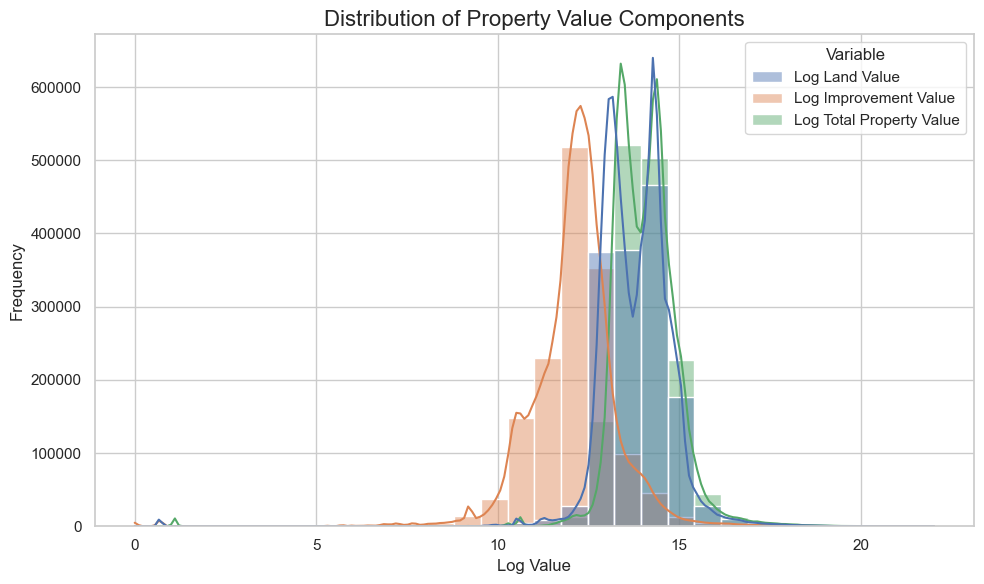

In [11]:
# Visual comparison of derived property value components
plot_df = df_tax_eda[['log_land_value', 'log_improvement_value', 'log_total_value']].melt(
    var_name='Variable',
    value_name='Log Value'
)

# Rename labels for cleaner display
plot_df['Variable'] = plot_df['Variable'].replace({
    'log_land_value': 'Log Land Value',
    'log_improvement_value': 'Log Improvement Value',
    'log_total_value': 'Log Total Property Value'
})

plt.figure(figsize=(10, 6))
sns.histplot(
    data=plot_df,
    x='Log Value',
    hue='Variable',
    bins=30,
    kde=True,
    alpha=0.45
)

plt.title("Distribution of Property Value Components", fontsize=16)
plt.xlabel("Log Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Distribution of Property Value Components (Log Scale)

The figure compares the distributions of land value, improvement value, and total property value after applying a log transformation.

Several key insights emerge:

- **Total property value closely follows land value**, indicating that land value is the primary driver of overall property valuation.
- **Improvement value is generally lower and more dispersed**, suggesting that building value contributes less consistently across properties.
- All three variables exhibit a **right-skewed distribution in their original form**, which becomes more symmetric after the log transformation.
- The log scale allows for a clearer comparison by reducing the impact of extreme high-value properties (outliers).

Overall, this visualization supports the decision to define `total_value` as the sum of land and improvement values and justifies the use of log transformations for further analysis and modeling.

## 4. Relationship Analysis

### Figure 3: Land Value vs Improvement Value

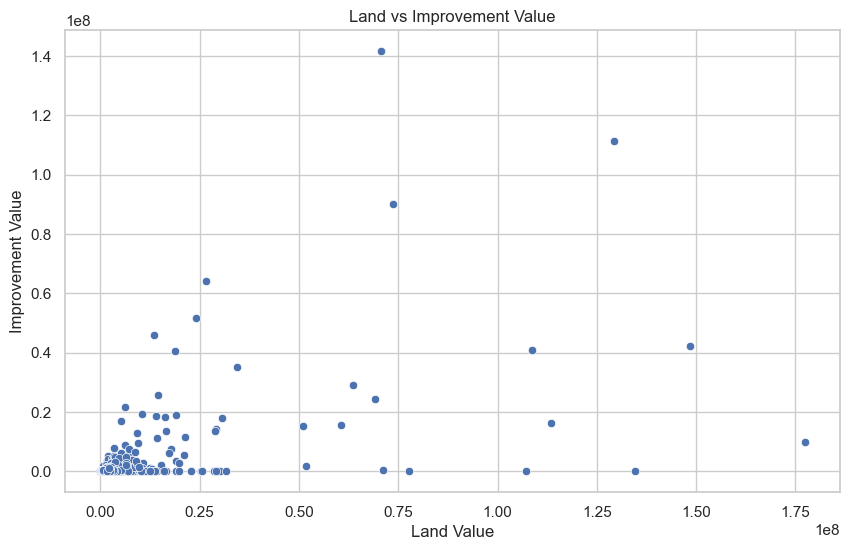

In [12]:
sns.scatterplot(
    data=df_tax_eda.sample(5000),
    x='current_land_value',
    y='current_improvement_value'
)
plt.title("Land vs Improvement Value")
plt.xlabel("Land Value")
plt.ylabel("Improvement Value")
plt.show()

### Interpretation

Land value appears to dominate total property value, especially at higher price levels.

### Implication

Location is likely a key driver of housing prices.

### Location-Related Importance

One of the main insights from Metro Vancouver housing analysis is that location strongly influences price patterns.  
In this dataset, land value acts as a location-related proxy, and it appears to be more influential than improvement value in explaining total property value.

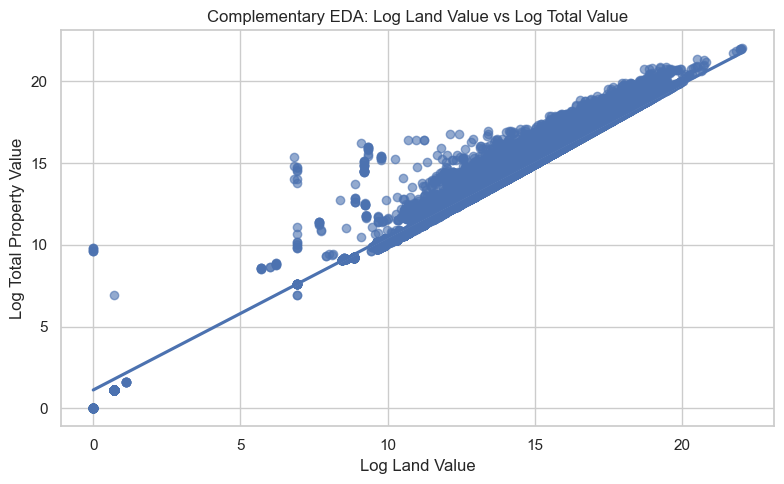

In [13]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df_tax_eda,
    x='log_land_value',
    y='log_total_value',
    scatter_kws={'alpha': 0.6}
)

plt.title("Complementary EDA: Log Land Value vs Log Total Value")
plt.xlabel("Log Land Value")
plt.ylabel("Log Total Property Value")
plt.tight_layout()
plt.show()

The plot shows a strong positive linear relationship between land value and total property value.  
This suggests that location-related components are central to housing valuation and may be more important than building-related components alone.

Improvement value also has a positive relationship with total property value, but the association is weaker and more dispersed than the relationship observed for land value.  
This indicates that structural components matter, but they do not appear to dominate pricing as strongly as land-related factors.

## 5. Market Segmentation

### Market Segmentation Perspective

To better understand variation in the housing market, property values can also be grouped into segments.  
This helps reveal whether high-value properties behave differently from low- and medium-value properties.

The categories are clearly separated, and the median property value increases from Low to Medium to High.  
This supports the usefulness of segmentation and suggests that high-value properties may represent a more heterogeneous market segment.

In [14]:
df_tax_eda['price_segment'] = pd.qcut(
    df_tax_eda['total_value'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

### Summary Statistics by Segment

In [15]:
segment_means = df_tax_eda.groupby('price_segment')[
    ['total_value', 'current_land_value', 'current_improvement_value', 'property_age']
].mean().round(2)

segment_means

C:\Users\alelu\AppData\Local\Temp\ipykernel_50376\3637792076.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_means = df_tax_eda.groupby('price_segment')[


,total_value,current_land_value,current_improvement_value,property_age
price_segment,,,,
Low,589206.34,433578.02,155628.32,26.47
Medium,1265934.76,1041601.10,224333.66,39.30
High,4743078.64,3706148.57,1036930.08,51.37


### Figure 4: Property Value by Segment

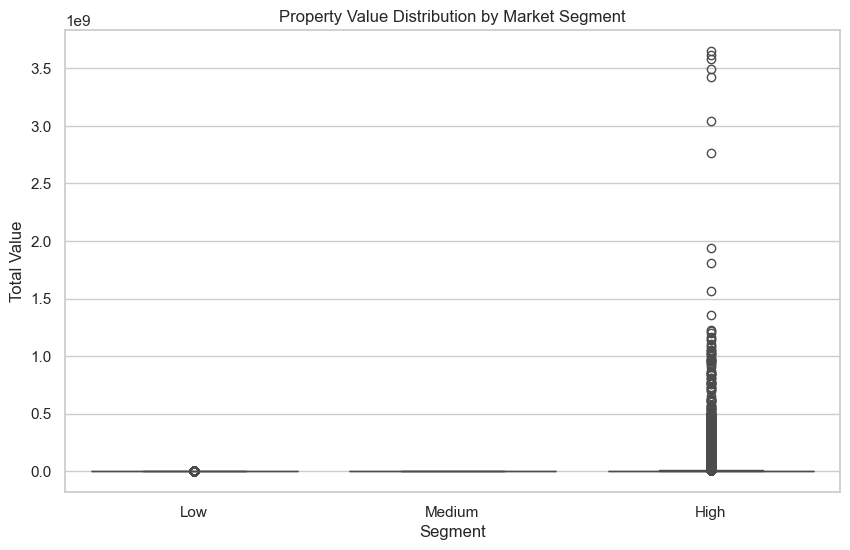

In [16]:
sns.boxplot(
    data=df_tax_eda,
    x='price_segment',
    y='total_value'
)
plt.title("Property Value Distribution by Market Segment")
plt.xlabel("Segment")
plt.ylabel("Total Value")
plt.show()

### Interpretation

The High-value segment shows significantly higher values and greater variability.

Land value increases disproportionately in higher segments.

### Implication

The housing market is heterogeneous and high-value properties behave differently.

### Next Step

We evaluate external influences such as crime.

## 6. Crime Data Integration

Figure X: Crime Distribution Across Neighbourhoods

In [17]:
crime_by_area = (
    df_crime.groupby('neighbourhood')
    .size()
    .reset_index(name='crime_count')
    .sort_values('crime_count', ascending=False)
)

print(crime_by_area.head(10))

                neighbourhood  crime_count
1   Central Business District       234279
22                   West End        77892
11             Mount Pleasant        55963
3                    Fairview        54603
19                 Strathcona        54161
14        Renfrew-Collingwood        48355
4          Grandview-Woodland        48203
9                   Kitsilano        43444
6    Kensington-Cedar Cottage        41939
5            Hastings-Sunrise        30270


Figure X: Crime Distribution Across Neighbourhoods

# Crime concentration (top vs rest)


In [18]:
top_10_crime = crime_by_area.head(10)['crime_count'].sum()
total_crime = crime_by_area['crime_count'].sum()

print(f"Top 10 neighbourhoods account for {top_10_crime/total_crime:.2%} of total crime incidents.")

Top 10 neighbourhoods account for 78.64% of total crime incidents.


Figure Z: Crime Variability

In [19]:
crime_variability = crime_by_area['crime_count'].describe()
print(crime_variability)

count        24.000000
mean      36510.041667
std       46833.338014
min         979.000000
25%       11118.250000
50%       21731.500000
75%       48241.000000
max      234279.000000
Name: crime_count, dtype: float64


## 7. Summary Statistics

In [26]:
df_tax_eda[['total_value', 'current_land_value', 'current_improvement_value']].describe()

,total_value,current_land_value,current_improvement_value
count,1.482050e+06,1.482050e+06,1.482050e+06
mean,2.198675e+06,1.726532e+06,4.721432e+05
std,1.239683e+07,9.718579e+06,5.054232e+06
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,7.030000e+05,5.150000e+05,1.050000e+05
50%,1.256000e+06,1.015000e+06,1.970000e+05
75%,2.065400e+06,1.769000e+06,3.270000e+05
max,3.648569e+09,3.637869e+09,1.136633e+09


### Interpretation

Large differences between mean and median confirm skewness and outliers.

### Implication

Transformations and robust models are necessary.

### Market Segmentation Insight

Properties were grouped into low-, medium-, and high-value segments using quantiles of total property value.

This segmentation helps compare whether higher-value properties differ in terms of land value, improvement value, and property age.

If the High segment shows clearly higher land values and more variability, this suggests that premium properties behave differently from the rest of the market.

C:\Users\alelu\AppData\Local\Temp\ipykernel_44556\579913529.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_seg.groupby('price_segment').agg({


total_value            current_land_value  \
                     mean     median               mean   
price_segment                                             
Low             589525.71   611000.0          433545.43   
Medium         1265818.99  1256500.0         1037997.78   
High           4876069.61  2601000.0         3834576.41   

              current_improvement_value property_age  
                                   mean         mean  
price_segment                                         
Low                           155980.28        28.46  
Medium                        227821.21        41.30  
High                         1041493.20        53.38

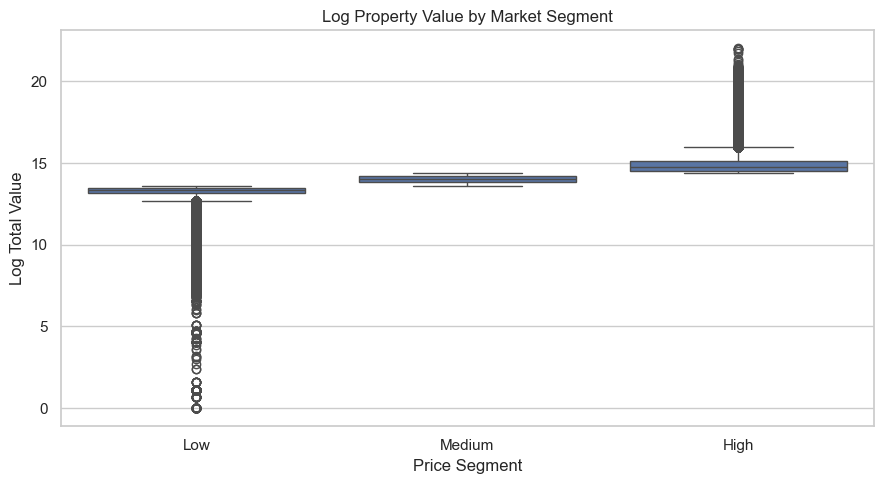

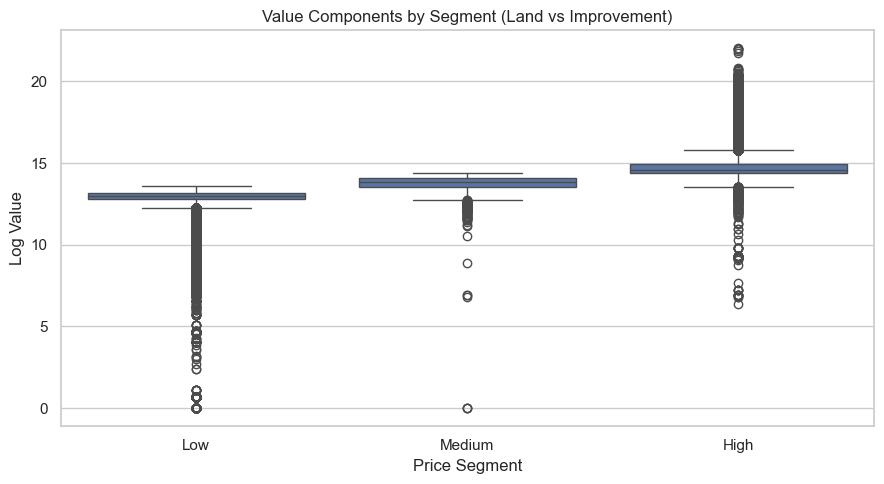

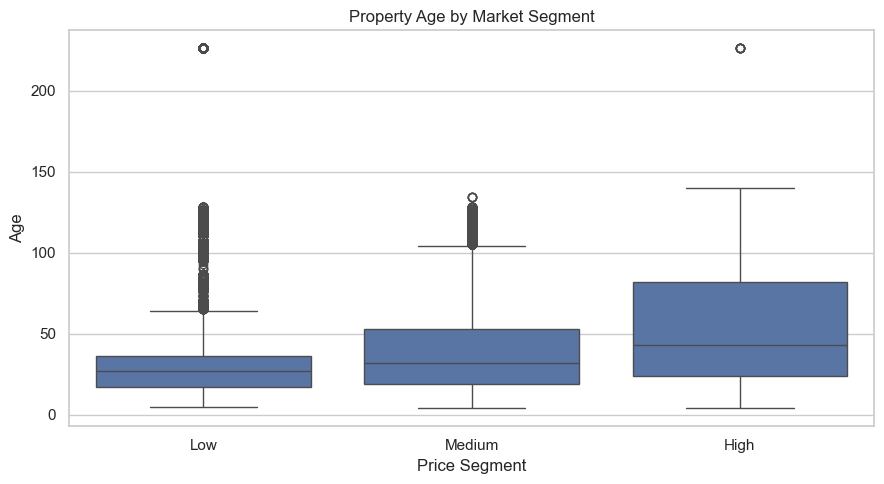


 INSIGHTS:

- High-value properties have an average total value of 4,876,070,
  compared to 589,526 in the low segment.
- Land value is significantly higher in premium properties, suggesting location plays a key role.
- High-value properties are not necessarily newer, indicating value is driven more by location than age.


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
sns.set_context("notebook")

# Copy dataset
df_seg = df_tax.copy()

# Create total value if needed
if 'total_value' not in df_seg.columns:
    df_seg['total_value'] = (
        df_seg['current_land_value'] + df_seg['current_improvement_value']
    )

# Property age
df_seg['property_age'] = 2026 - df_seg['year_built']

# Segmentation (quantiles)
df_seg['price_segment'] = pd.qcut(
    df_seg['total_value'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# -------------------------------
# 📊 SUMMARY TABLE
# -------------------------------
summary = df_seg.groupby('price_segment').agg({
    'total_value': ['mean', 'median'],
    'current_land_value': ['mean'],
    'current_improvement_value': ['mean'],
    'property_age': ['mean']
}).round(2)

display(summary)

# -------------------------------
# 📈 VISUAL 1 — DISTRIBUTION
# -------------------------------
plt.figure(figsize=(9,5))
sns.boxplot(
    data=df_seg,
    x='price_segment',
    y=np.log1p(df_seg['total_value'])
)
plt.title("Log Property Value by Market Segment")
plt.xlabel("Price Segment")
plt.ylabel("Log Total Value")
plt.tight_layout()
plt.show()

# -------------------------------
# 📈 VISUAL 2 — LAND VS IMPROVEMENT
# -------------------------------
plt.figure(figsize=(9,5))
sns.boxplot(
    data=df_seg.melt(
        id_vars='price_segment',
        value_vars=['current_land_value','current_improvement_value'],
        var_name='component',
        value_name='value'
    ),
    x='price_segment',
    y=np.log1p(df_seg['current_land_value']),
)
plt.title("Value Components by Segment (Land vs Improvement)")
plt.xlabel("Price Segment")
plt.ylabel("Log Value")
plt.tight_layout()
plt.show()

# -------------------------------
# 📈 VISUAL 3 — AGE
# -------------------------------
plt.figure(figsize=(9,5))
sns.boxplot(
    data=df_seg,
    x='price_segment',
    y='property_age'
)
plt.title("Property Age by Market Segment")
plt.xlabel("Price Segment")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

# -------------------------------
# 🤖 AUTO INSIGHTS
# -------------------------------
high = summary.loc['High']
low = summary.loc['Low']

print("\n🔍 AUTOMATED INSIGHTS:\n")

print(f"- High-value properties have an average total value of {high[('total_value','mean')]:,.0f},")
print(f"  compared to {low[('total_value','mean')]:,.0f} in the low segment.")

if high[('current_land_value','mean')] > low[('current_land_value','mean')]:
    print("- Land value is significantly higher in premium properties, suggesting location plays a key role.")

if high[('property_age','mean')] < low[('property_age','mean')]:
    print("- High-value properties tend to be newer.")
else:
    print("- High-value properties are not necessarily newer, indicating value is driven more by location than age.")

### Market Segmentation Analysis

To better understand variation in the housing market, properties were grouped into three segments (Low, Medium, High) based on total property value.

This segmentation reveals that:

- High-value properties exhibit significantly higher land values, suggesting that location is a major driver of property prices.
- The variation within the high-value segment is also larger, indicating a more heterogeneous market at the upper end.
- Property age does not necessarily decrease with higher value, implying that newer construction is not the only determinant of premium pricing.

Overall, this analysis highlights structural differences across market segments and supports the idea that high-end properties behave differently from lower-value properties.

### 5. Why This Matters for the Next Stage

A key lesson from similar Metro Vancouver housing work is that strong predictive performance depends not only on the model itself, but also on data integration, cleaning, and feature design.

In this project, the EDA suggests three important directions for the next stage:

- use derived value variables such as total property value,
- preserve location-related information because land value is highly informative,
- and consider external neighborhood features such as crime in later feature engineering.

## 8. Key Insights

1. Property values are highly skewed and require transformation.
2. Land value is the primary driver of total property value.
3. The housing market is heterogeneous, with distinct behavior across segments.
4. High-value properties show greater variability and different dynamics.
5. Crime shows a weak but noticeable relationship with property values.
6. Integrating external datasets improves analytical depth and modeling readiness.

This EDA provides a strong foundation for predictive modeling and feature engineering.

## Final Complementary Insights

The combined EDA suggests that property values are highly skewed and influenced by outliers, making transformation techniques useful for both interpretation and future modeling.

Among the available variables, land value shows the strongest relationship with total property value, supporting the view that location-related factors are central to housing valuation.

Improvement value also contributes positively, but its relationship is weaker than that of land value.

The separate crime analysis further shows that neighborhood conditions vary across areas, which motivates the inclusion of contextual external features in future stages.

Overall, the EDA supports the next phase of the project: creating engineered features that combine property structure, value composition, and location-related information for house price prediction.